# The Suites [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maxencefaldor/bbobax/blob/main/notebooks/01_suites.ipynb)

In this notebook, we tour the three suites bbobax ships, each faithful to its official reference:

- **bbob** -- the 24 standard noiseless functions (Hansen et al., 2009), verified value-for-value against the official implementation.
- **bbob-noisy** -- f101-f130, eight of those functions under the three official noise models.
- **Many-Affine** -- MA-BBOB (Vermetten et al.), a continuous *space* of problems blended from the 24.

A suite in bbobax is nothing more than a `dict[str, BBOBProblem]`. There is no registry and no special type -- which means building your own suite is a dict comprehension, shown at the end.

## Install

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [ ]:
%pip install -U "jax[cuda]"

Then, install bbobax from PyPi:

In [ ]:
%pip install -U "bbobax[notebooks]"

## Import

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bbobax import ManyAffine, Sphere, bbob_noisy_suite, bbob_suite

In [2]:
seed = 0

key = jax.random.key(seed)

## bbob: the 24 standard functions

One surface per function, at $D = 2$ with the optimum pinned to the origin and rotations off, so the landscape structure itself is what shows. Surfaces whose values span more than three orders of magnitude are drawn in $\log_{10}$ scale and marked so in their title -- a rule computed from the data, since anything else either flattens `bent_cigar` or distorts `sphere`. The five COCO groups read left to right, top to bottom: separable (f1-f5), low or moderate conditioning (f6-f9), high conditioning and unimodal (f10-f14), multimodal with adequate global structure (f15-f19), multimodal with weak global structure (f20-f24).

In [3]:
def surface(problem, params, ax, key):
    """Draw one problem instance as a 3-D surface, in log scale if it needs it."""
    grid = jnp.linspace(*problem.x_range, 100)
    X, Y = jnp.meshgrid(grid, grid)
    points = jnp.stack([X.ravel(), Y.ravel()], axis=-1)

    fitness = jax.vmap(lambda p: problem.evaluate(key, p, params).fitness)(points)
    Z = fitness.reshape(X.shape) - jnp.min(fitness)

    log = jnp.max(Z) > 1e3  # spans more than three orders of magnitude
    if log:
        Z = jnp.log10(Z + 1e-8)

    ax.plot_surface(X, Y, Z, cmap="viridis_r", antialiased=True, alpha=0.8)
    ax.set_title(f"{problem.name} (log)" if log else problem.name)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

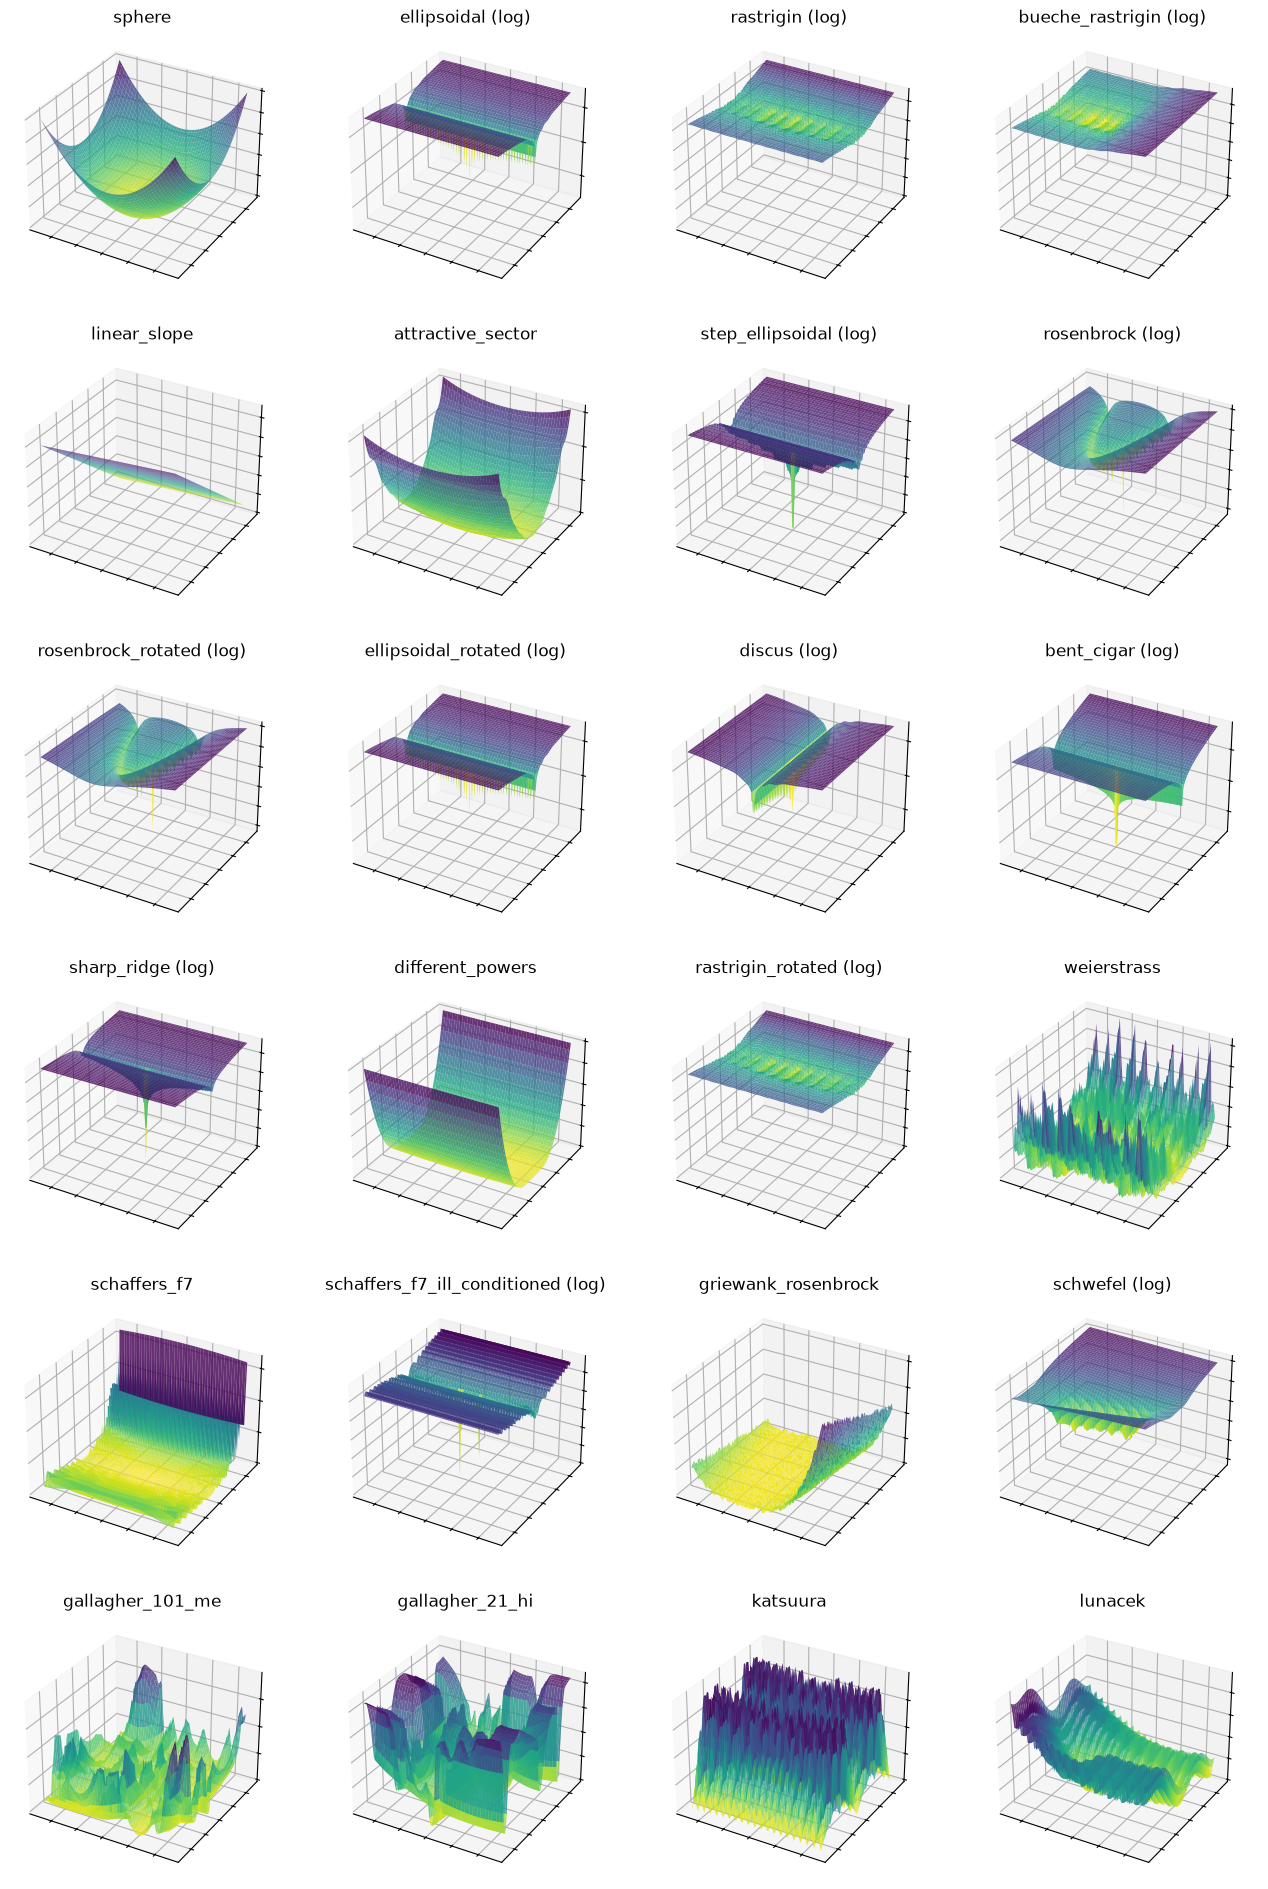

In [4]:
problems = bbob_suite(
    num_dims=2, x_opt_range=(0.0, 0.0), f_opt_range=(0.0, 0.0), sample_rotation=False
)

fig, axes = plt.subplots(6, 4, figsize=(16, 24), subplot_kw={"projection": "3d"})
for ax, problem in zip(axes.ravel(), problems.values()):
    key, subkey = jax.random.split(key)
    surface(problem, problem.sample(subkey), ax, subkey)
plt.show()

## bbob-noisy: f101-f130

The noisy suite pairs eight of the noiseless functions with the three official noise models -- Gaussian (multiplicative), uniform (multiplicative, heavier), and Cauchy (additive, outlier-producing) -- at the paper's two severities: *moderate* for f101-f106, *severe* for f107 onward.

A landscape plot cannot show noise, so we show what noise *is*: the same instance asked twice. A `Noisy` problem and its bare base draw identical instances from the same key, so for each point we can plot the true value against one noisy measurement of it. Two structural facts are visible: the Gaussian and uniform models scatter multiplicatively (bands around the diagonal in log-log), while Cauchy is additive -- a constant shift punctuated by outliers -- and below the target precision $10^{-8}$ every model returns the true value untouched, so noise never hides a solved problem.

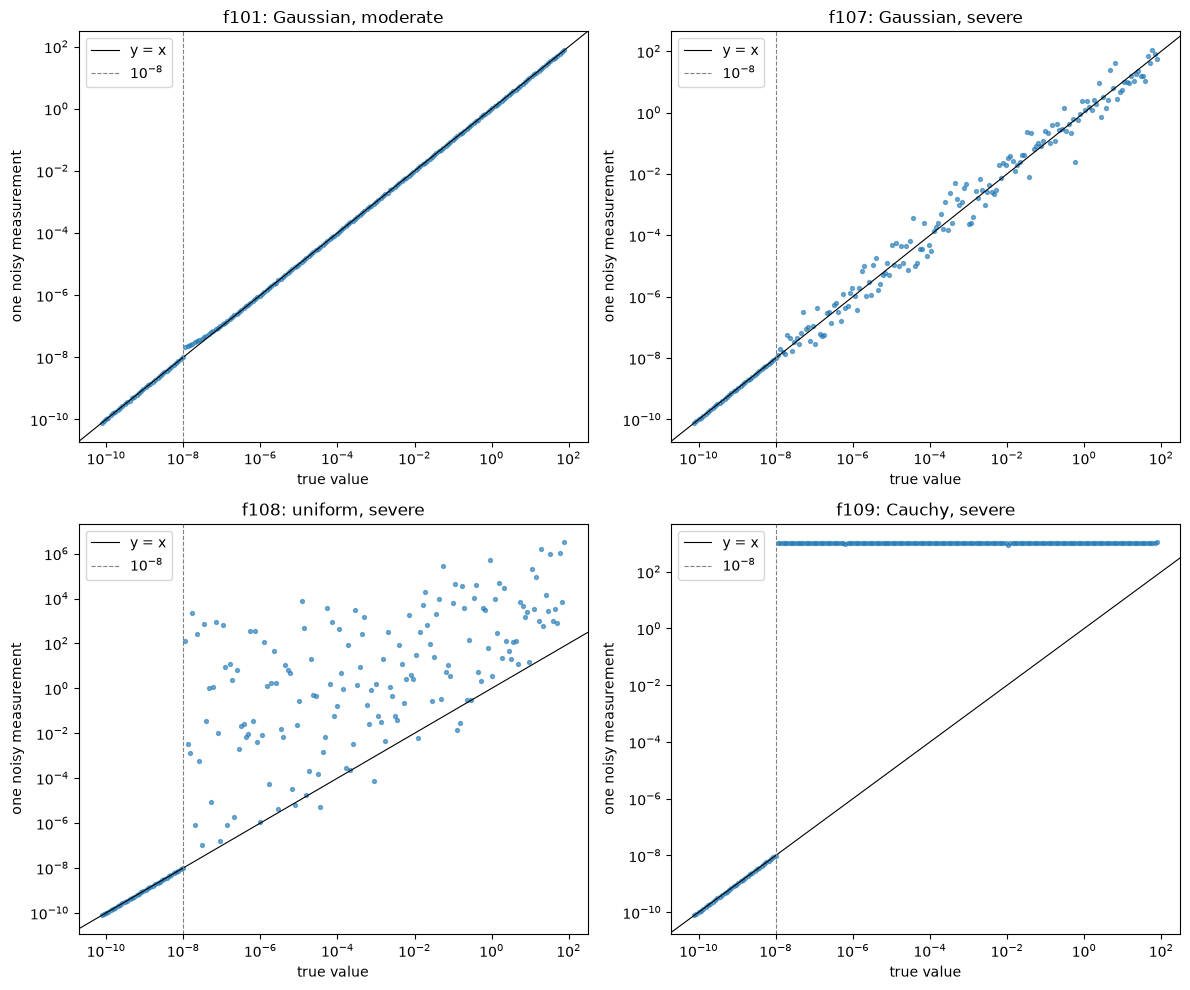

In [5]:
noisy = bbob_noisy_suite(["f101", "f107", "f108", "f109"], num_dims=5)
base = Sphere(num_dims=5)
titles = {
    "f101": "f101: Gaussian, moderate",
    "f107": "f107: Gaussian, severe",
    "f108": "f108: uniform, severe",
    "f109": "f109: Cauchy, severe",
}

key, key_instance, key_x = jax.random.split(key, 3)
# Points spanning many orders of magnitude of true value: shrink toward x_opt.
base_params = base.sample(key_instance)
x = base.sample_x(key_x)
points = base_params.x_opt + jnp.logspace(-6, 0, 200)[:, None] * (
    x - base_params.x_opt
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, problem) in zip(axes.ravel(), noisy.items()):
    params = problem.sample(key_instance)  # same key: same instance as the base
    keys = jax.random.split(jax.random.key(int(name[1:])), len(points))
    true = jax.vmap(lambda p: base.evaluate(keys[0], p, base_params).fitness)(points)
    measured = jax.vmap(problem.evaluate, in_axes=(0, 0, None))(
        keys, points, params
    ).fitness

    ax.scatter(true, measured, s=8, alpha=0.6)
    ax.axline((1e-8, 1e-8), slope=1, color="black", linewidth=0.8, label="y = x")
    ax.axvline(1e-8, color="gray", linestyle="--", linewidth=0.8, label="$10^{-8}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(titles[name])
    ax.set_xlabel("true value")
    ax.set_ylabel("one noisy measurement")
    ax.legend()
plt.tight_layout()
plt.show()

## Many-Affine: a space of problems

MA-BBOB draws a sparse weight vector over all 24 functions and blends their values in log space. Where a suite offers 24 landscapes, `ManyAffine` offers a continuum between them -- each instance below is a different blend, drawn like any other instance. This is the natural held-out test set for anything meta-learned on the 24.

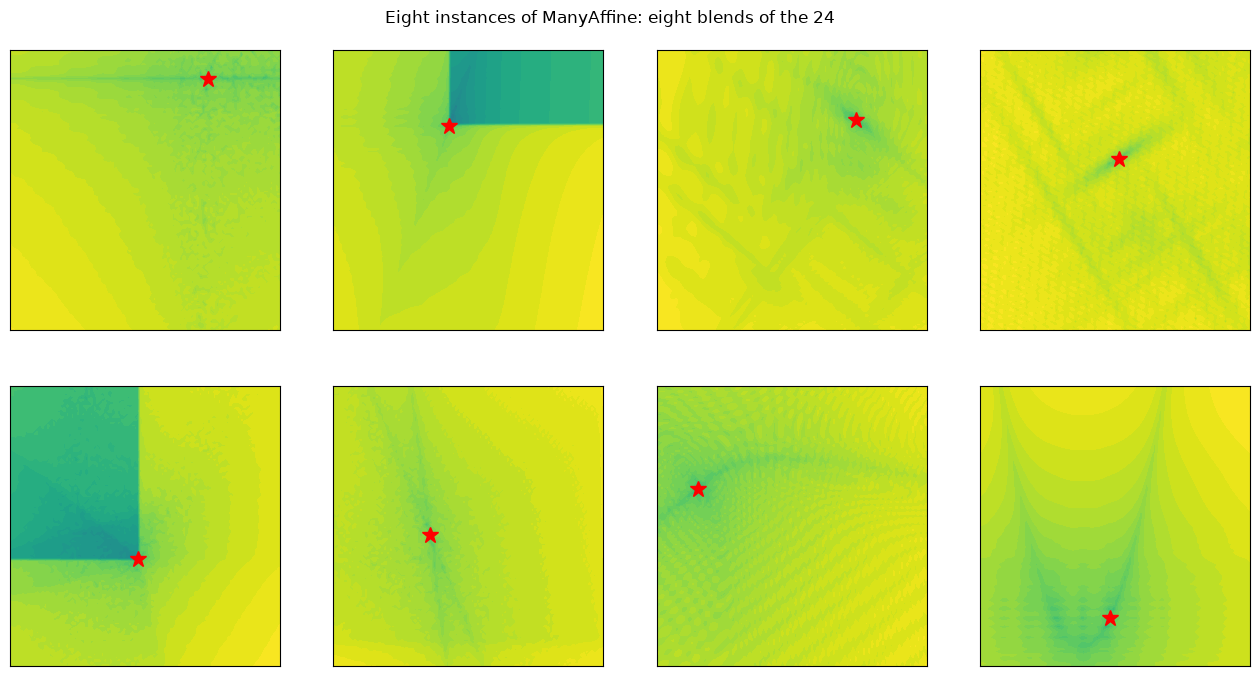

In [6]:
problem = ManyAffine(num_dims=2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.ravel():
    key, subkey = jax.random.split(key)
    params = problem.sample(subkey)

    grid = jnp.linspace(*problem.x_range, 100)
    X, Y = jnp.meshgrid(grid, grid)
    points = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    fitness = jax.vmap(lambda p: problem.evaluate(subkey, p, params).fitness)(points)
    Z = jnp.log10(fitness.reshape(X.shape) - jnp.min(fitness) + 1e-8)

    ax.contourf(X, Y, Z, levels=50, cmap="viridis")
    ax.plot(*params.x_opt, "r*", markersize=12)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Eight instances of ManyAffine: eight blends of the 24", y=0.93)
plt.show()

## Your own suite

A suite is a dict, so composing one is a comprehension -- here, a small testbed of one function per difficulty regime, at the dimension of your choice:

In [7]:
from bbobax import BentCigar, Katsuura, Rastrigin, RosenbrockRotated

my_suite = {
    problem_class.name: problem_class(num_dims=10)
    for problem_class in (RosenbrockRotated, BentCigar, Rastrigin, Katsuura)
}
list(my_suite)

['rosenbrock_rotated', 'bent_cigar', 'rastrigin', 'katsuura']

## Next

- [02_bbo](02_bbo.ipynb) -- optimizing one problem with an evolution strategy.
- [03_benchmarking](03_benchmarking.ipynb) -- comparing optimizers across the whole suite, the COCO way.